# 1. Introduction

This notebook analyzes customer churn for a telecom company using the Telco Customer Churn dataset. The goal is to understand churn patterns, prepare the data for modeling, compare supervised learning models, identify the strongest churn drivers, and translate the findings into retention recommendations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None

sns.set_theme(style="whitegrid")

# 2. Dataset description

In [2]:
data = pd.read_csv("Telco-Customer-Churn.csv")
print(data.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
blank_total_charges = (data["TotalCharges"] == " ").sum()
blank_total_charges

np.int64(11)

In [6]:
data[data["TotalCharges"].str.strip() == ""][["customerID", "TotalCharges"]]

,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


# 3. Data cleaning

In [7]:
data["TotalCharges"] = data["TotalCharges"].replace(" ", np.nan)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

In [8]:
data.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
data = data.dropna().reset_index(drop=True)

In [10]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
data = data.drop(columns=["customerID"], errors="ignore")

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


In [13]:
for col in data.columns:
    if data[col].dtype == "object":
        print(f"{col} unique values: {data[col].unique()}")

gender unique values: ['Female' 'Male']


Partner unique values: ['Yes' 'No']
Dependents unique values: ['No' 'Yes']
PhoneService unique values: ['No' 'Yes']
MultipleLines unique values: ['No phone service' 'No' 'Yes']
InternetService unique values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity unique values: ['No' 'Yes' 'No internet service']
OnlineBackup unique values: ['Yes' 'No' 'No internet service']
DeviceProtection unique values: ['No' 'Yes' 'No internet service']
TechSupport unique values: ['No' 'Yes' 'No internet service']
StreamingTV unique values: ['No' 'Yes' 'No internet service']
StreamingMovies unique values: ['No' 'Yes' 'No internet service']
Contract unique values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling unique values: ['Yes' 'No']
PaymentMethod unique values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn unique values: ['No' 'Yes']


# 4. Exploratory Data Analysis

In [14]:
churn_counts=data["Churn"].value_counts()
print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


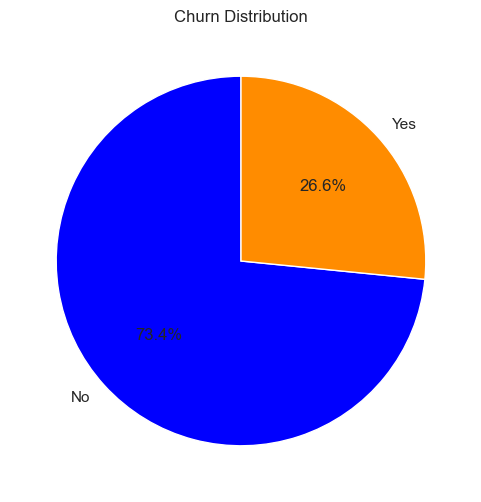

In [15]:
plt.figure(figsize=(6,6))
plt.pie(churn_counts,labels=churn_counts.index,autopct="%1.1f%%",startangle=90,shadow=False,colors=["blue","darkorange"])
plt.title("Churn Distribution")
plt.show()

### Insight
The dataset is imbalanced: about 73.4% of customers did not churn and 26.6% did churn. Because churn is the minority class, model evaluation should look beyond accuracy and include precision, recall, and F1-score.

## Churn patterns and feature relationships

In [16]:
# divide the data into two groups based on churn status
churned = data[data['Churn'] == 'Yes']
not_churned = data[data['Churn'] == 'No']

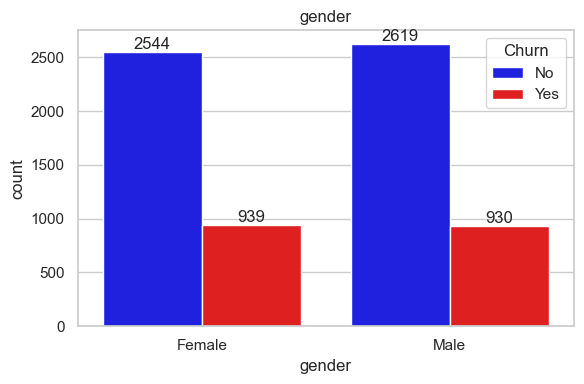

In [17]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'gender'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Churn is almost identical by gender: female customers churn at about 27.0% and male customers at about 26.2%. Gender does not appear to be a strong standalone churn driver in this dataset.

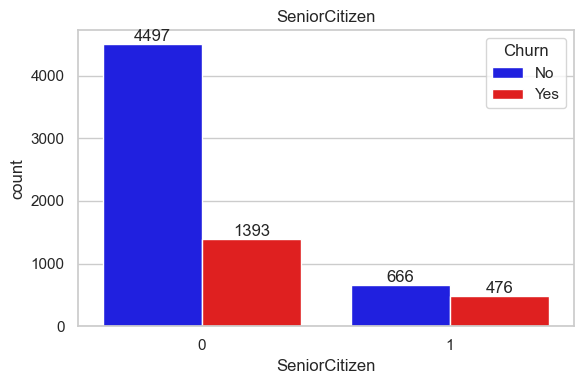

In [18]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'SeniorCitizen'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Senior citizens have a much higher churn rate, about 41.7% compared with 23.7% for non-senior customers. Age segment may therefore be useful for targeted retention strategies.

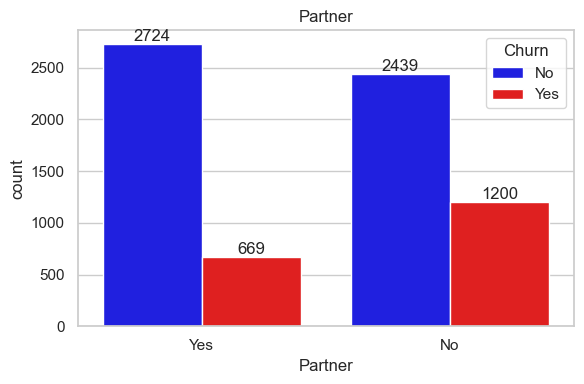

In [19]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'Partner'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers without a partner churn more often, about 33.0% versus 19.7% for customers with a partner. This suggests customers with stronger household ties are more stable.

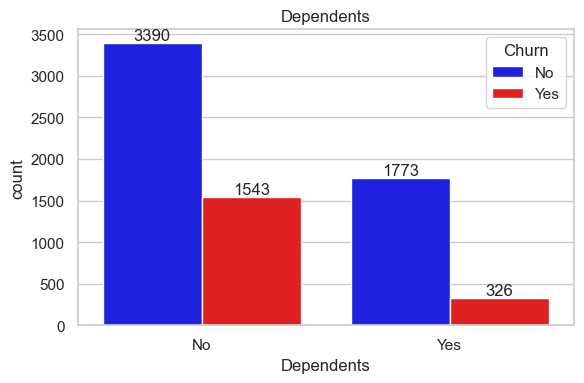

In [20]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'Dependents'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers without dependents churn at about 31.3%, while customers with dependents churn at about 15.5%. Having dependents is associated with noticeably higher retention.

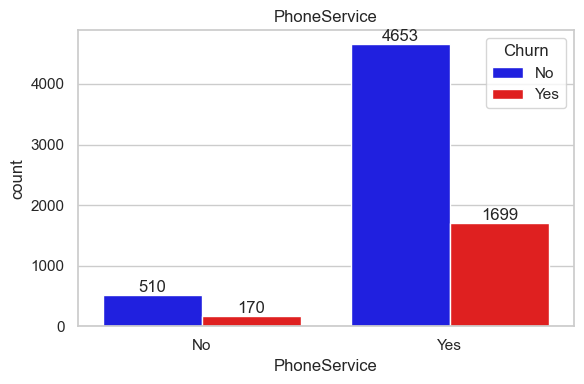

In [21]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'PhoneService'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Phone service status shows very little separation: customers with phone service churn at about 26.7%, while those without phone service churn at about 25.0%. This feature alone is unlikely to explain much churn.

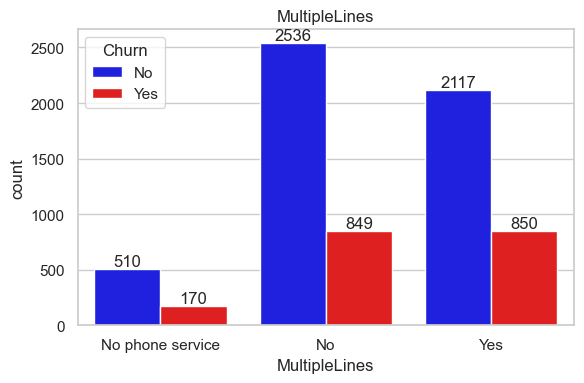

In [22]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'MultipleLines'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers with multiple lines churn slightly more often, about 28.6%, compared with roughly 25% for customers without multiple lines or phone service. The difference exists, but it is modest.

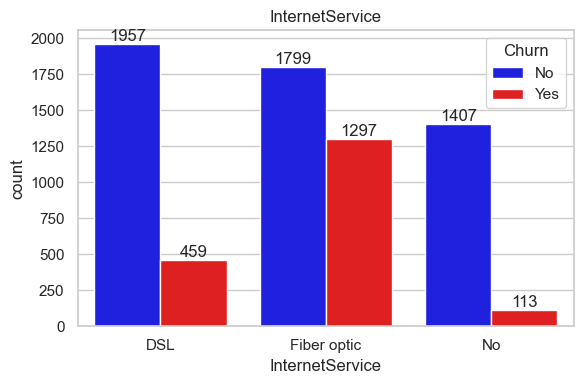

In [23]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'InternetService'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Fiber optic customers have the highest churn rate at about 41.9%, compared with 19.0% for DSL and only 7.4% for customers without internet service. Internet service type is one of the clearest churn signals.

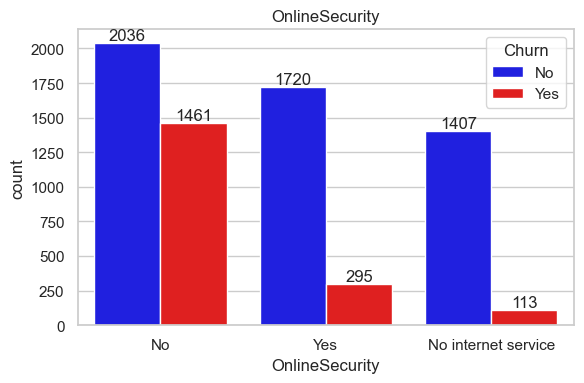

In [24]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'OnlineSecurity'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers without online security churn at about 41.8%, while customers with online security churn at about 14.6%. Security add-ons appear strongly associated with customer retention.

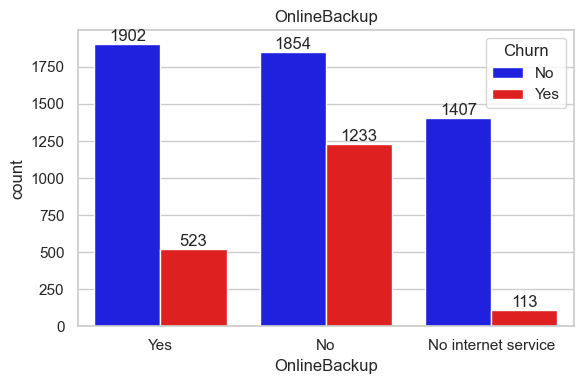

In [25]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'OnlineBackup'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers without online backup churn at about 39.9%, compared with 21.6% for those with online backup. Add-on services may increase customer stickiness.

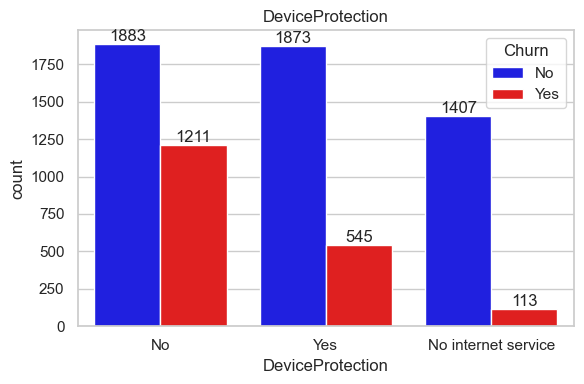

In [26]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'DeviceProtection'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers without device protection churn at about 39.1%, while those with device protection churn at about 22.5%. Protection services seem linked to lower churn risk.

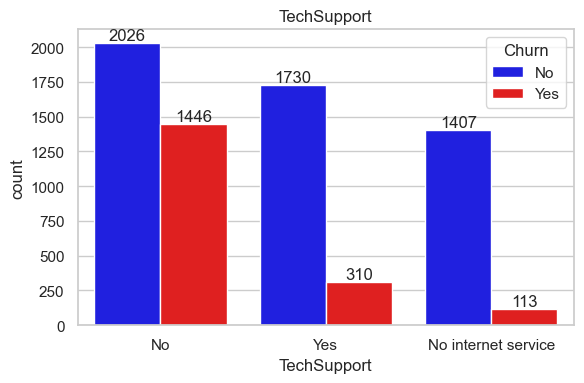

In [27]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'TechSupport'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers without tech support churn at about 41.6%, compared with only 15.2% for customers with tech support. Support availability looks like a major retention factor.

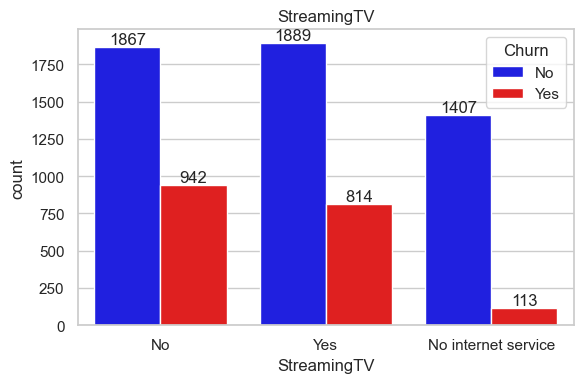

In [28]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'StreamingTV'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Streaming TV does not separate churn as strongly as support or security features. Customers with streaming TV churn at about 30.1%, while those without it churn at about 33.5%.

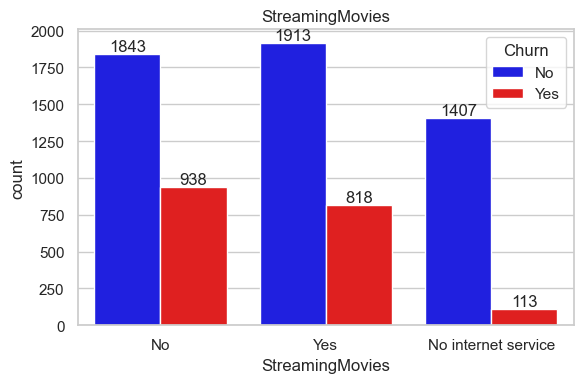

In [29]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'StreamingMovies'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Streaming Movies shows a similar pattern to Streaming TV: churn is about 30.0% for users with the service and 33.7% for users without it. Entertainment add-ons are weaker churn indicators than contract or support features.

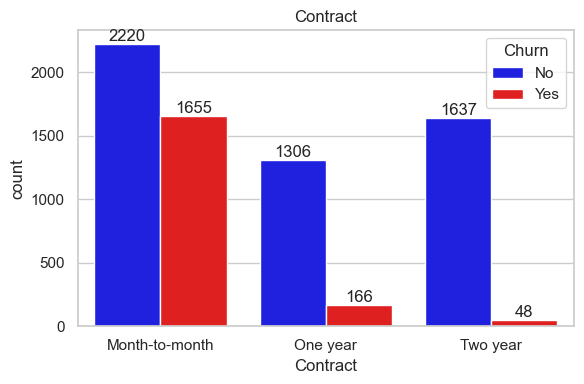

In [30]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'Contract'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Month-to-month contracts dominate churn: about 42.7% of those customers churn, compared with 11.3% for one-year contracts and 2.8% for two-year contracts. Contract length is one of the strongest retention signals.

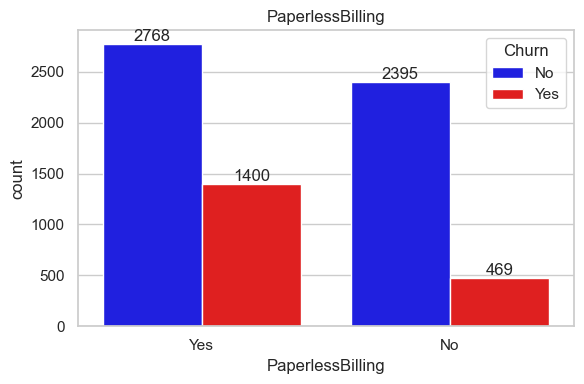

In [31]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'PaperlessBilling'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Customers using paperless billing churn at about 33.6%, more than double the 16.4% churn rate for customers without paperless billing. This may reflect overlap with digital-first plans and electronic payment behavior.

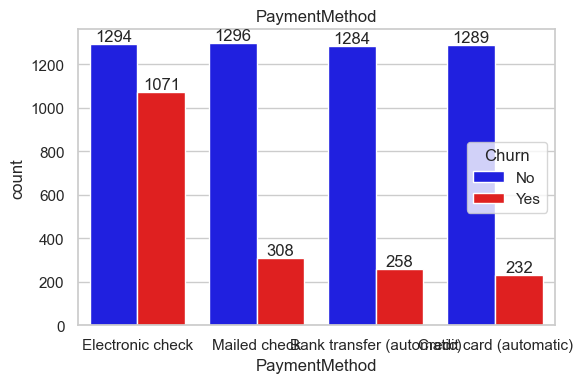

In [32]:
colors = {'Yes': 'red', 'No': 'blue'}
predictor = 'PaymentMethod'

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=predictor, hue='Churn', palette=colors)
plt.title(predictor)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

##### Electronic check customers have the highest churn rate at about 45.3%, far above automatic bank transfer at 16.7%, automatic credit card at 15.3%, and mailed check at 19.2%. Payment method is a strong churn indicator.

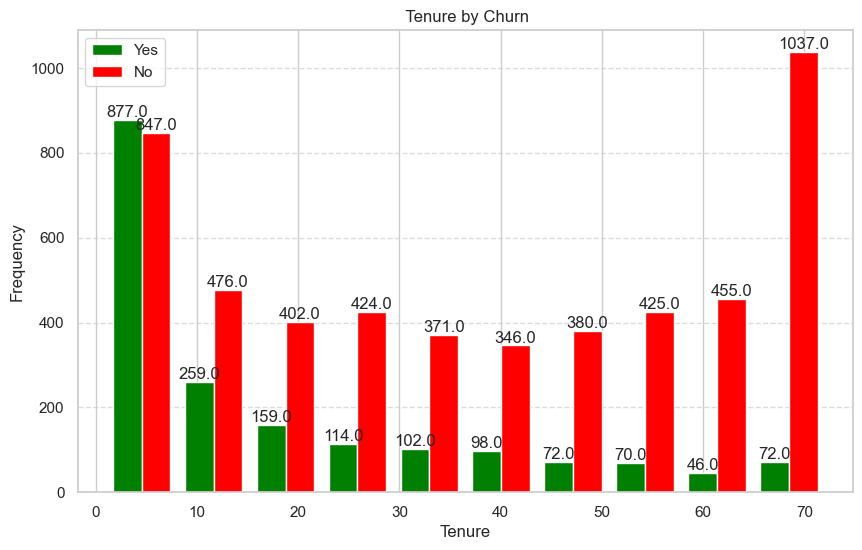

In [33]:
# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['tenure'], not_churned['tenure']], bins=10, color=['green', 'red'], label=['Yes', 'No'])
plt.title(' Tenure by Churn')
plt.xlabel('Tenure')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')

##### Churn is concentrated among newer customers. The median tenure for churned customers is about 10 months, compared with about 38 months for customers who stayed, so early-life retention is especially important.

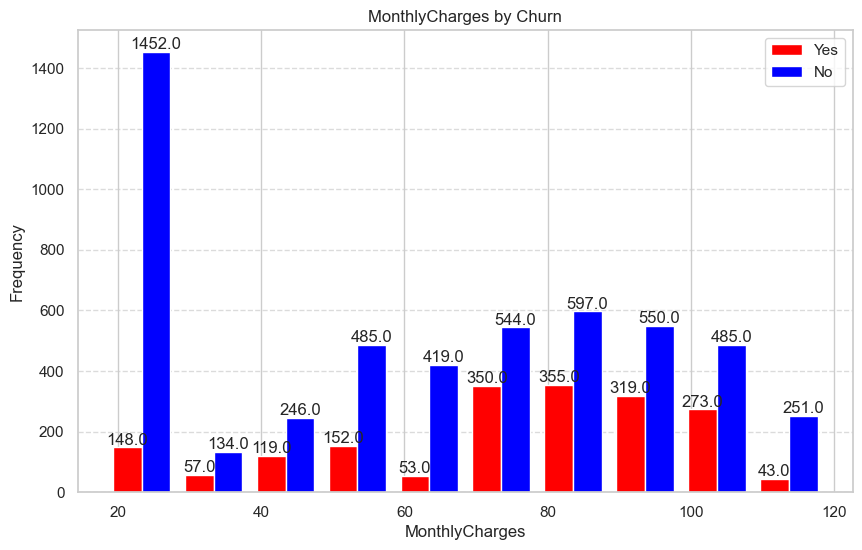

In [34]:
# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['MonthlyCharges'], not_churned['MonthlyCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title('MonthlyCharges by Churn')
plt.xlabel('MonthlyCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')

##### Customers who churned tend to have higher monthly bills. Their median MonthlyCharges are about 79.65 compared with 64.45 for customers who stayed, suggesting price sensitivity may contribute to churn.

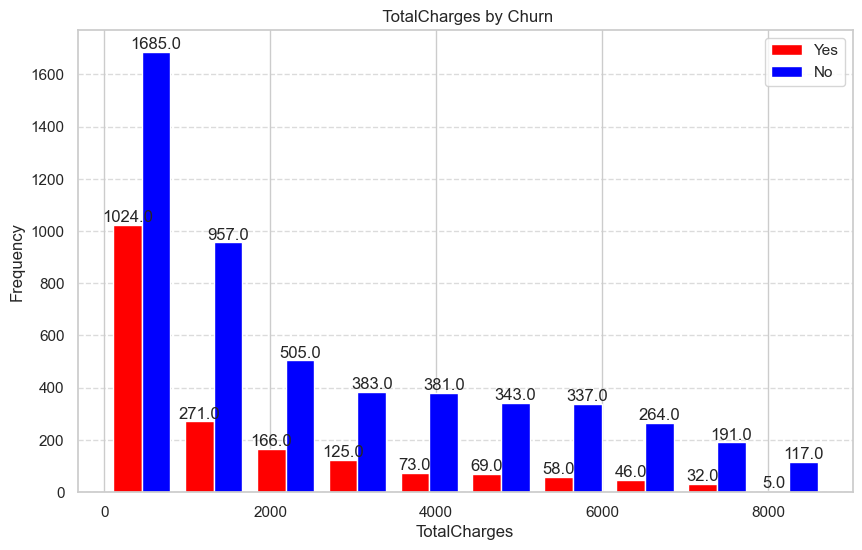

In [35]:
# make plot for tenure
churned = data[data['Churn'] == 'Yes']
not_churned = data[data['Churn'] == 'No']

# Plotting
plt.figure(figsize=(10, 6))
plt.hist([churned['TotalCharges'], not_churned['TotalCharges']], bins=10, color=['red', 'blue'], label=['Yes', 'No'])
plt.title(' TotalCharges by Churn')
plt.xlabel('TotalCharges')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Add text on top of bars
for rect in plt.gca().patches:
    height = rect.get_height()
    plt.gca().text(rect.get_x() + rect.get_width() / 2, height, height, ha='center', va='bottom')


##### Churned customers generally have lower TotalCharges, with a median of about 703.55 compared with 1683.60 for non-churned customers. This mainly reflects that many churners leave early before accumulating large lifetime charges.

<Axes: xlabel='Contract', ylabel='count'>

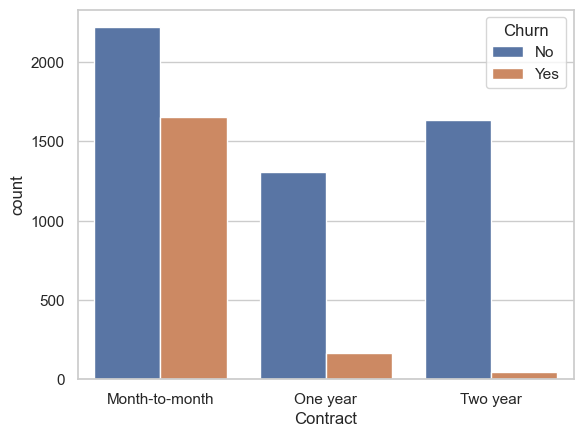

In [36]:
sns.countplot(x="Contract", hue="Churn", data=data)

##### The raw countplot shows that most churners are on month-to-month contracts. Longer contracts have far fewer churn cases, reinforcing the idea that commitment length is closely tied to retention.

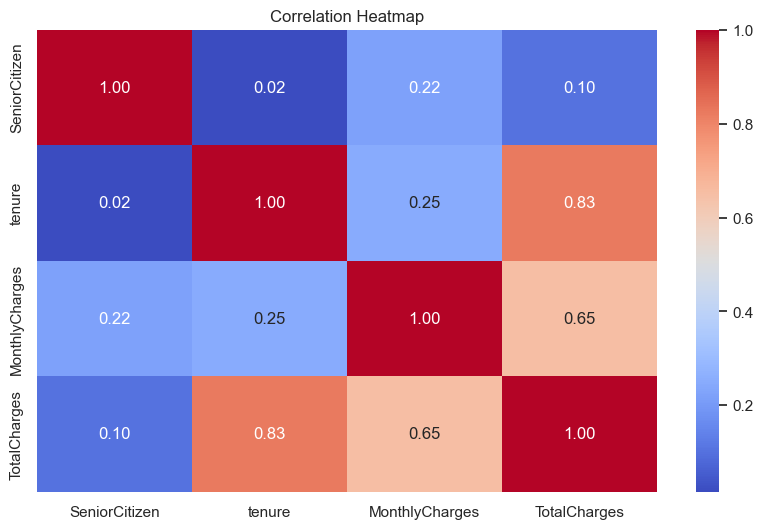

In [37]:
# Plotting correlation heatmap for numeric features 
plt.figure(figsize=(10, 6))
sns.heatmap(
    data.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

##### This heatmap compares the numeric variables in the current dataset. Tenure and TotalCharges are strongly correlated, about 0.83, while MonthlyCharges and TotalCharges are also positively related, about 0.65. Churn is still categorical at this point, so it is not included in this correlation matrix unless it is encoded first.

### MonthlyCharges vs Churn

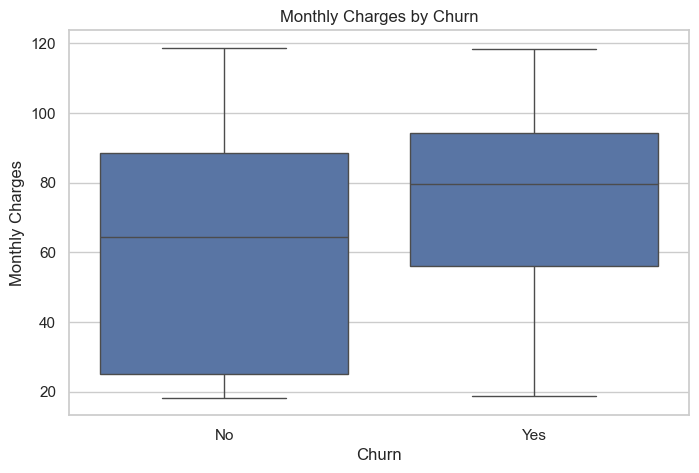

In [38]:
# Boxplot for MonthlyCharges by Churn 
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

##### The MonthlyCharges boxplot shows churned customers paying more overall. The churned group has a higher median monthly charge, about 79.65, which supports the pattern seen in the histogram.

### TotalCharges vs Churn

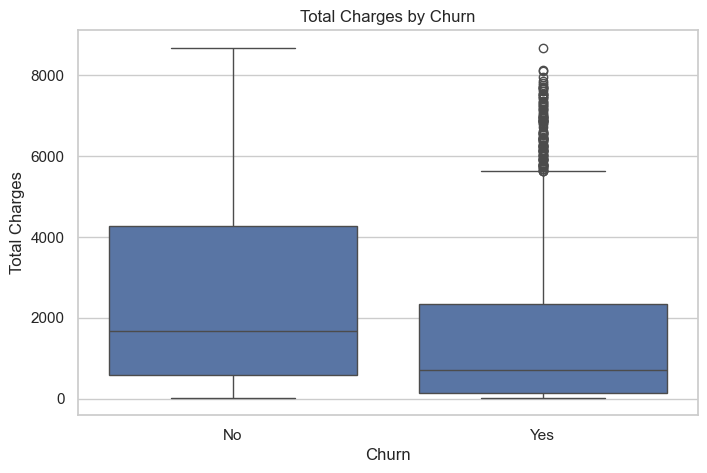

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="TotalCharges", data=data)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

##### The TotalCharges boxplot shows non-churned customers with higher accumulated charges. This is consistent with their longer tenure, while churned customers are concentrated at lower total spend because many leave earlier.

### Tenure vs Churn

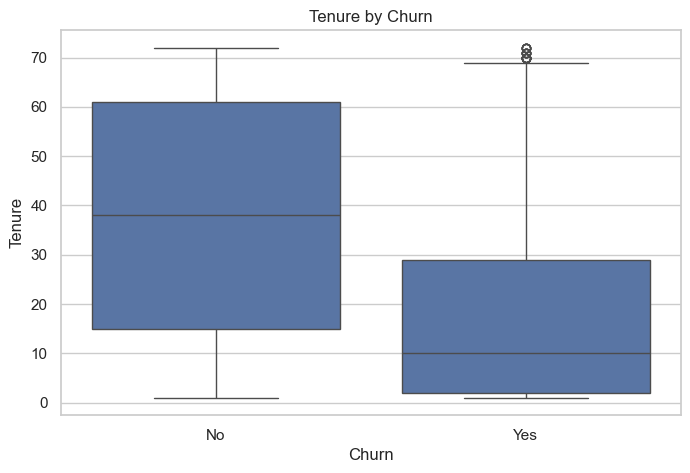

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="Churn", y="tenure", data=data)

plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

##### The Tenure boxplot shows a clear retention gap: churned customers have a much lower median tenure, about 10 months, while non-churned customers have a median around 38 months. Tenure is a key churn signal.

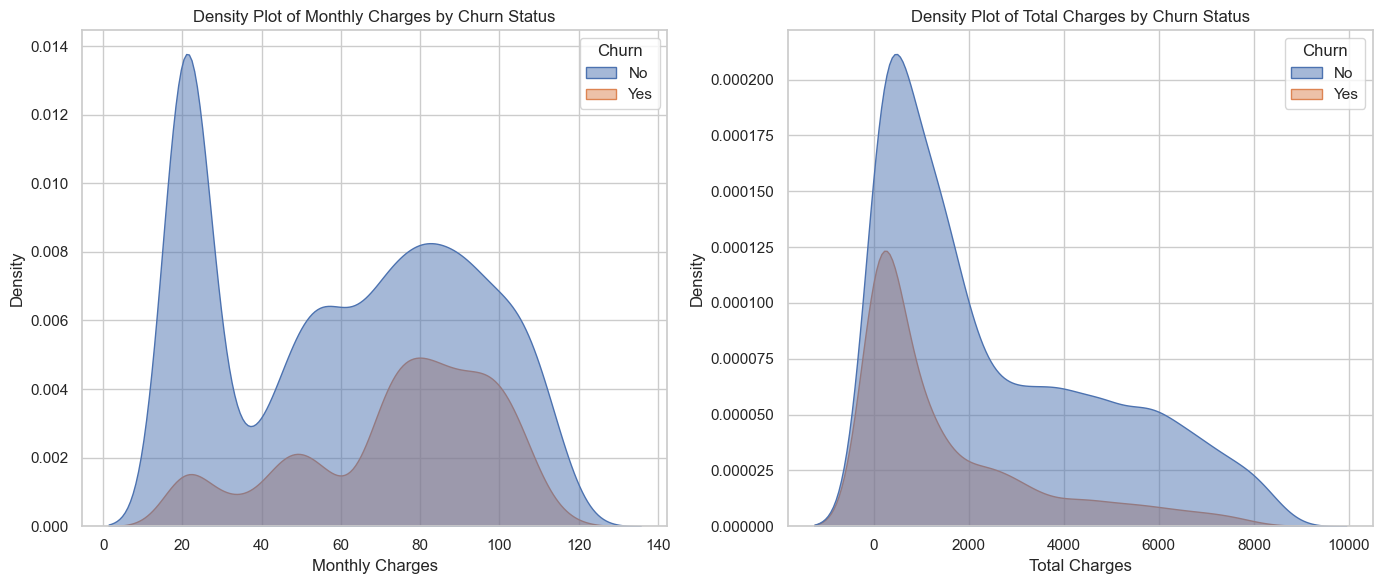

In [41]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Monthly Charges
sns.kdeplot(data=data, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[0])
axes[0].set_title('Density Plot of Monthly Charges by Churn Status')
axes[0].set_xlabel('Monthly Charges')
axes[0].set_ylabel('Density')

# Plot for Total Charges
sns.kdeplot(data=data, x="TotalCharges", hue="Churn", fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Density Plot of Total Charges by Churn Status')
axes[1].set_xlabel('Total Charges')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

##### The density plots combine the earlier patterns: churners cluster at higher MonthlyCharges but lower TotalCharges. This points to customers who pay relatively high monthly fees but leave before becoming long-tenure, high-lifetime-value customers.

## Normalized categorical churn rates

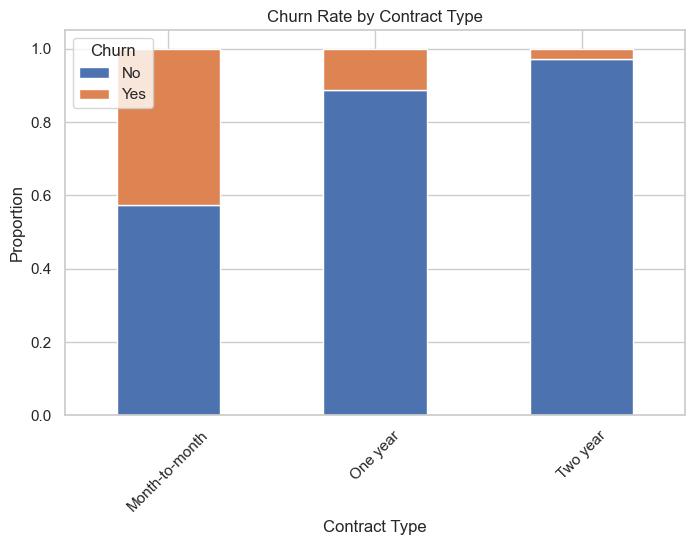

In [42]:
contract_churn = pd.crosstab(data["Contract"], data["Churn"], normalize="index")

contract_churn.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Proportion")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()

##### When normalized by contract type, the churn gap becomes very clear: month-to-month customers churn at about 42.7%, compared with 11.3% for one-year and 2.8% for two-year contracts. Encouraging longer contracts could reduce churn risk.

### InternetService vs Churn

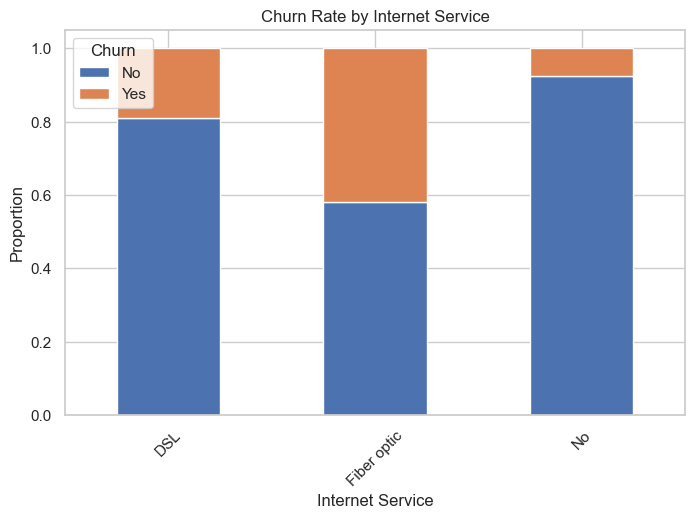

In [43]:
internet_churn = pd.crosstab(data["InternetService"], data["Churn"], normalize="index")

internet_churn.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Proportion")
plt.legend(title="Churn")
plt.xticks(rotation=45)
plt.show()

##### The normalized InternetService chart shows that fiber optic customers churn at about 41.9%, much higher than DSL at 19.0% and customers with no internet service at 7.4%. Fiber optic customers should be a priority segment for churn investigation.

### PaymentMethod vs Churn

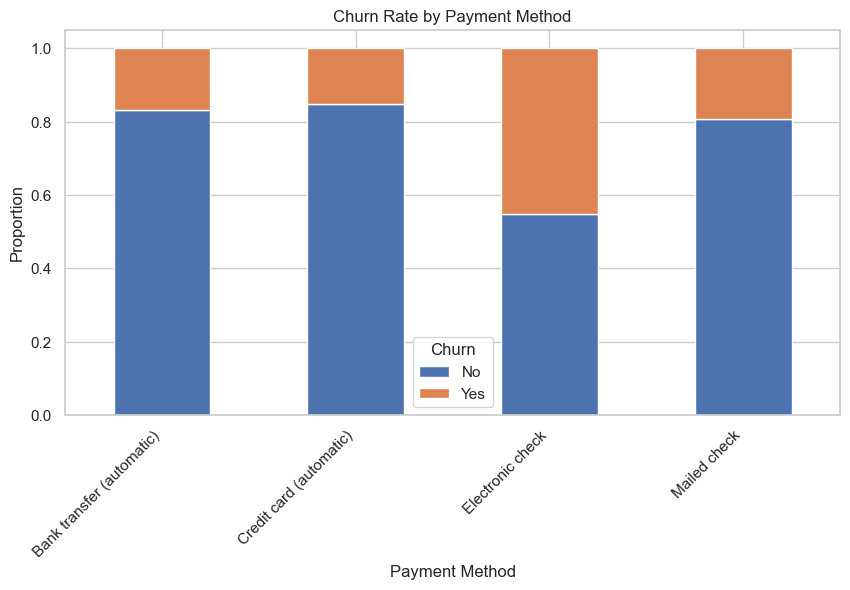

In [44]:
payment_churn = pd.crosstab(data["PaymentMethod"], data["Churn"], normalize="index")

payment_churn.plot(kind="bar", stacked=True, figsize=(10, 5))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Proportion")
plt.legend(title="Churn")
plt.xticks(rotation=45, ha="right")
plt.show()

##### The normalized PaymentMethod chart highlights electronic check as the riskiest method, with about 45.3% churn. Automatic payment methods have much lower churn rates, around 15-17%, making payment behavior an important retention signal.

# 5. Preprocessing

In [45]:
import dashboard_core as core

# Training and inference now share one fitted preprocessing/model artifact.
PREDICTION_FEATURES = core.FEATURE_FIELDS
X = data[PREDICTION_FEATURES].copy()
y = (data["Churn"] == "Yes").astype(int)
artifacts = core.get_model_artifacts()
best_model = artifacts["pipeline"]
best_model_name = artifacts["model_name"]

print("Prediction features:", PREDICTION_FEATURES)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Saved model:", best_model_name)

Prediction features: ['tenure', 'Contract', 'TotalCharges', 'InternetService', 'MonthlyCharges', 'PaymentMethod']
X shape: (7032, 6)
y shape: (7032,)
Saved model: Random Forest


# 6. Model training

In [46]:
# Candidate selection uses only training-set cross-validation.
# train_model.py performs calibration, threshold selection, holdout evaluation,
# and final fitting; the notebook reads those generated results.
scores_data = artifacts["model_comparison"].set_index("Model")
display(scores_data)
print("Selection rule:", artifacts["model_selection"])
print("Selected model:", best_model_name)
print(f"Decision threshold: {artifacts['decision_threshold']:.3f}")

,Accuracy,Precision,Recall,F1-score,F1 std
Model,,,,,
Random Forest,0.763022,0.536862,0.788629,0.638819,0.010593
Logistic Regression,0.742400,0.509751,0.813378,0.626644,0.009091
Gradient Boosting,0.792889,0.641548,0.503679,0.563632,0.011499


Selection rule: Highest mean 5-fold training-set CV F1
Selected model: Random Forest
Decision threshold: 0.286


# 7. Model evaluation

,Holdout score
Accuracy,0.747690
Precision,0.516995
Recall,0.772727
F1-score,0.619507
ROC-AUC,0.838946
PR-AUC,0.641826
Brier score,0.138926


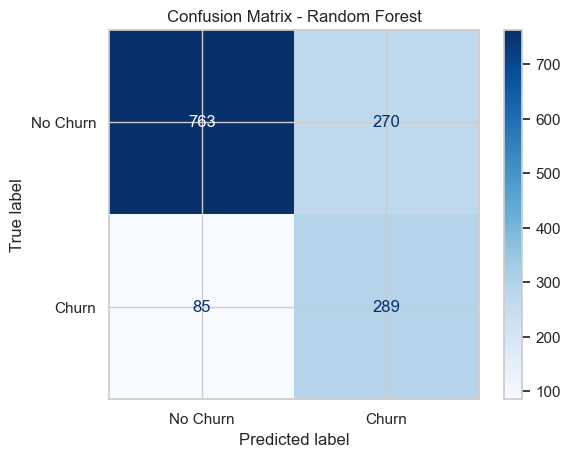

In [47]:
metrics_data = pd.DataFrame.from_dict(artifacts["metrics"], orient="index", columns=["Holdout score"])
display(metrics_data)

cm = artifacts["confusion_matrix"]
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"],
)

disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# 8. Feature importance

Best model: Random Forest
Importance type: Feature importance

Top individual encoded features:


,Feature,Importance
0,numeric__tenure,0.235685
4,categorical__Contract_Two year,0.173159
2,numeric__TotalCharges,0.134116
5,categorical__InternetService_Fiber optic,0.123361
1,numeric__MonthlyCharges,0.121317
8,categorical__PaymentMethod_Electronic check,0.080840
3,categorical__Contract_One year,0.072713
6,categorical__InternetService_No,0.046018
9,categorical__PaymentMethod_Mailed check,0.007716
7,categorical__PaymentMethod_Credit card (automa...,0.005074



Top original feature groups:


,OriginalFeature,Importance
0,Contract,0.245872
5,tenure,0.235685
1,InternetService,0.169379
4,TotalCharges,0.134116
2,MonthlyCharges,0.121317
3,PaymentMethod,0.093630



Key churn-driver ranks:


,Rank,OriginalFeature,Importance
0,1,Contract,0.245872
1,2,tenure,0.235685
2,3,InternetService,0.169379
3,4,TotalCharges,0.134116
4,5,MonthlyCharges,0.121317
5,6,PaymentMethod,0.093630


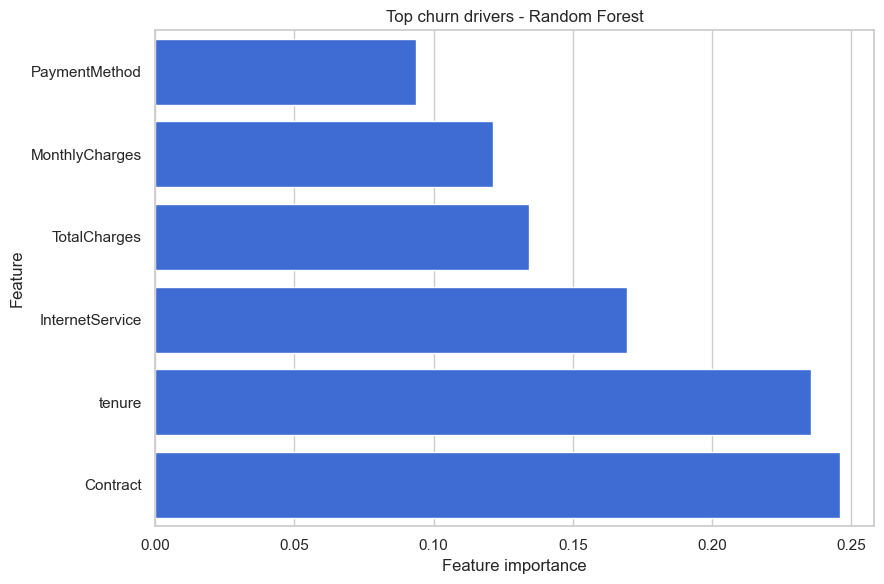

In [48]:
feature_importance = artifacts["feature_importance"].copy()
feature_group_importance = artifacts["grouped_importance"].copy()
importance_label = "Feature importance" if best_model_name != "Logistic Regression" else "Absolute coefficient"

print(f"Best model: {best_model_name}")
print(f"Importance type: {importance_label}")

print("\nTop individual encoded features:")
display(feature_importance[["Feature", "Importance"]].head(15))

print("\nTop original feature groups:")
display(feature_group_importance.head(10))

focus_features = PREDICTION_FEATURES
feature_ranks = feature_group_importance.reset_index(drop=True).copy()
feature_ranks["Rank"] = feature_ranks.index + 1
focus_summary = feature_ranks[feature_ranks["OriginalFeature"].isin(focus_features)]

print("\nKey churn-driver ranks:")
display(focus_summary[["Rank", "OriginalFeature", "Importance"]])

plt.figure(figsize=(9, 6))
plot_data = feature_group_importance.head(10).sort_values("Importance", ascending=True)
sns.barplot(data=plot_data, x="Importance", y="OriginalFeature", color="#2563eb")
plt.title(f"Top churn drivers - {best_model_name}")
plt.xlabel(importance_label)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature importance insight

In the reduced prediction setup, the model keeps only the strongest churn drivers: tenure, contract type, total charges, internet service, monthly charges, and payment method.

- **tenure** is the top driver: customers with shorter tenure are more likely to churn, which matches the earlier tenure plots.
- **Contract** is also highly important: month-to-month customers are much riskier than customers on one-year or two-year contracts.
- **TotalCharges**, **InternetService**, **MonthlyCharges**, and **PaymentMethod** are retained because they are the next strongest predictors after tenure and contract.

Note: `feature_importances_` measures how strongly the model uses each feature, but it does not show direction by itself. Use the EDA charts, permutation importance, or SHAP values to explain whether a feature increases or decreases churn risk.


# 9. Business recommendations

- Prioritize early-tenure customers, especially during the first year, because churn is concentrated among newer customers.
- Create targeted offers for month-to-month customers and encourage migration to one-year or two-year contracts.
- Review high monthly bills for at-risk customers and propose right-sized plans before price sensitivity turns into churn.
- Investigate fiber optic customer experience, since this segment shows a high observed churn rate.
- Encourage automatic payment for customers using electronic check, because payment method remains one of the retained prediction features.

# 10. Conclusion

The cleaned dataset contains 7,032 usable customer records after handling blank `TotalCharges` values. Churn is imbalanced, with about 26.6% of customers leaving. The best saved model run selected Random Forest by F1-score, and the main churn drivers are tenure, contract type, total charges, internet service, monthly charges, and payment method.

The strongest business message is that churn prevention should focus on early-tenure, month-to-month, high-monthly-charge, and electronic-check customer segments.